# Pandas, NumPy, and Matplotlib Practice

Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## DataFrames

DataFrames are the main data structure we will use from pandas!

DataFrame: single or 2-dimensional mutable data structure with labeled axes.

First, let's create a list and visualize it by printing it out

In [2]:
myList = [13, 24, 12, 45, 25]
print(myList)

[13, 24, 12, 45, 25]


We can create the list as a DataFrame using the DataFrame() function from pandas

Print your list as a DataFrame:

In [3]:
df_list = pd.DataFrame(myList)
print(df_list)

    0
0  13
1  24
2  12
3  45
4  25


DataFrames also work with grids (2-D lists or arrays)

First, create a 2-D list and print it as an array

In [4]:
myGrid = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

arrGrid = np.array(myGrid)
print(arrGrid)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


Let's see what a 2-D list looks like as a DataFrame

In [5]:
df_grid = pd.DataFrame(arrGrid)
print(df_grid)

   0  1  2
0  1  2  3
1  4  5  6
2  7  8  9


## Naming Columns

DataFrames have a ".columns" attribute that will allow us to name the columns using a list.

Name the columns of your grid!

In [6]:
df_grid.columns = ["potato", "pineapple", "squash"]
print(df_grid)

   potato  pineapple  squash
0       1          2       3
1       4          5       6
2       7          8       9


To make a DataFrame with already-named columns, use a dictionary where the keys are the column names

First, let's make a dictionary with the keys "Horse", "Distance", and "Time"

Let the value for "Horse" be a list of horse names, the value for "Distance" be a list of distances travelled, and "Time" be time taken to travel that far

In [7]:
myDict = {
    "Horse": ["Secretariat", "Kelso", "Seabiscuit", "The Rock"],
    "Distance": [60, 80, 45, 74],
    "Time": [2.5, 3.8, 2.9, 4.0]
}

print(myDict)

{'Horse': ['Secretariat', 'Kelso', 'Seabiscuit', 'The Rock'], 'Distance': [60, 80, 45, 74], 'Time': [2.5, 3.8, 2.9, 4.0]}


Now turn the dictionary into a DataFrame and print it out!

In [8]:
df_dict = pd.DataFrame(myDict)
print(df_dict)

         Horse  Distance  Time
0  Secretariat        60   2.5
1        Kelso        80   3.8
2   Seabiscuit        45   2.9
3     The Rock        74   4.0


## Retrieving Data and Plotting

You can retrive column data using <DF_NAME>.&lt;KEY>

Retrieve the times in a variable called "times" and retrieve the distances in a variable called "distances"

In [9]:
times = df_dict.Time
distances = df_dict.Distance

print(times)
print(distances)

0    2.5
1    3.8
2    2.9
3    4.0
Name: Time, dtype: float64
0    60
1    80
2    45
3    74
Name: Distance, dtype: int64


Make a scatterplot of distance vs. time (time on the x-axis):

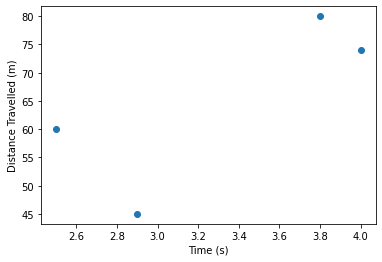

In [11]:
plt.scatter(times, distances)
plt.xlabel("Time (s)")
plt.ylabel("Distance Travelled (m)")
plt.show()

To color based on the horse names, use the DataFrame ".groupby()" attribute, where the column name is the parameter

.groupby() will return an iterable that gives the unique row value (in this case, horse names) and sections of the dataframe with the corresponding value you're grouping by (all data with the same horse name)

a legend can be plotted with plt.legend()

(to move the legend around, use the parameters "loc" and "bbox_to_anchor"; but this isn't normally required!)

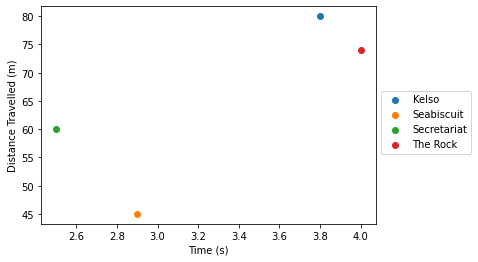

In [19]:
horse_groups = df_dict.groupby("Horse")

for name, group in horse_groups:
    plt.scatter(group.Time, group.Distance, label=name)

plt.legend(loc="lower center", bbox_to_anchor=(1.15, .3))
plt.xlabel("Time (s)")
plt.ylabel("Distance Travelled (m)")
plt.show()

## Adding Columns

Columns can be added to the DataFrame using dictionary comprehensions (i.e., in the same way you add keys to dictionaries)!

Let's try! Add a column called "Speed" that holds the speed (distance/time) of each horse

In [21]:
df_dict["Speed"] = df_dict.Distance / df_dict.Time

print(df_dict)

         Horse  Distance  Time      Speed
0  Secretariat        60   2.5  24.000000
1        Kelso        80   3.8  21.052632
2   Seabiscuit        45   2.9  15.517241
3     The Rock        74   4.0  18.500000


# Exercise: Plotting Flower Relationships

"iris.csv" holds data for measurements of 150 irises - 50 flowers of 3 different species.

There are 5 columns in the dataset:  
1. Sepal_Length: length of sepal in cm  
2. Sepal_Width: width of sepal in cm  
3. Petal_Length: length of petals in cm  
4. Petal_Width: width of petals in cm  
5. Class: species name (Iris-Setosa, Iris-Versicolour, Iris-Virginica)

pd.read_csv(<FILEPATH_FILENAME>) will read a csv file into a DataFrame object

Task:  
1. Read iris.csv into a variable called "iris" using pd.read_csv("data/iris.csv", header=None) and name the columns  
2. Make a scatter plot of one flower anatomy relationship (one measurement vs. another measurement)

Optional:  
3. Make the same scatterplot but color based on the species names

Label the x- and y- axes appropriately and include units!

In [22]:
iris = pd.read_csv("data/iris.csv", header=None)
print(iris)

       0    1    2    3               4
0    5.1  3.5  1.4  0.2     Iris-setosa
1    4.9  3.0  1.4  0.2     Iris-setosa
2    4.7  3.2  1.3  0.2     Iris-setosa
3    4.6  3.1  1.5  0.2     Iris-setosa
4    5.0  3.6  1.4  0.2     Iris-setosa
..   ...  ...  ...  ...             ...
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica

[150 rows x 5 columns]


In [24]:
iris.columns = ["Sepal_Length", "Sepal_Width", "Petal_Length", "Petal_Width", "Class"]
print(iris)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width           Class
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


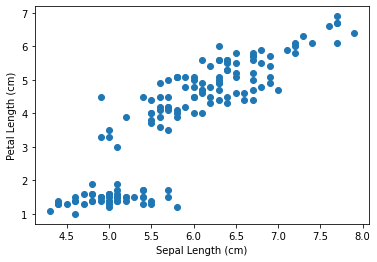

In [25]:
plt.scatter(iris.Sepal_Length, iris.Petal_Length)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.show()

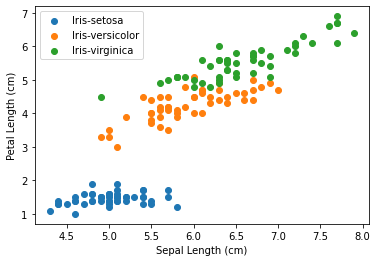

In [27]:
iris_groups = iris.groupby("Class")

for name, group in iris_groups:
    plt.scatter(group.Sepal_Length, group.Petal_Length, label=name)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()
plt.show()

This just scrapes the surface of what you can do with pandas and pyplot!

Other things you can look into:  
- plotting multiple plots in the same figure  
- specifying marker colors and shapes  
- three dimensional plots  
- animations
- resolving NaNs